# Automatic Differentiation & Backpropagation

深度学习训练用的求导引擎是**自动微分**：把复合函数拆成计算图，用链式法则精确传播梯度。本课从零手写一个迷你 autograd，再对比 torch，并分析反向传播为什么是唯一可行的方案。


## 0. 环境配置与导入


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import matplotlib

# 中文字体：避免图上中文显示为方块（macOS 用苹方，Windows 用微软雅黑）
matplotlib.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Arial Unicode MS", "Microsoft YaHei", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False   # 修复负号显示为方块

print("PyTorch version:", torch.__version__)
torch.manual_seed(42)


PyTorch version: 2.13.0


## 1. 三种求导方式对比


| 方式 | 做法 | 优点 | 缺点 |
|------|------|------|------|
| 数值微分 | 差分逼近 $(f(x{+}h)-f(x{-}h))/2h$ | 实现简单，可验证任意代码 | 有误差、每参数两次前向，$O(n)$ 次 |
| 符号微分 | 用规则化简表达式 $\sin(x^2)' \to 2x\cos(x^2)$ | 精确 | 表达式爆炸，难以处理控制流/循环 |
| 自动微分 | 计算图 + 链式法则，数值执行 | 精确、成本 $O(n)$、支持任意代码 | 需要构建/遍历计算图 |

关键区别：符号微分"化简公式"，自动微分"拆解计算过程"。对深度网络，只有自动微分是可行的。


## 2. 计算图


计算图把复合函数拆成基本运算节点。每个节点存两样东西：**前向值**（供上层使用）和**局部导数**（供反向传播使用）。以 $y = \sin(x^2 + 1)$ 为例：


Text(0.5, 1.0, '计算图示意')

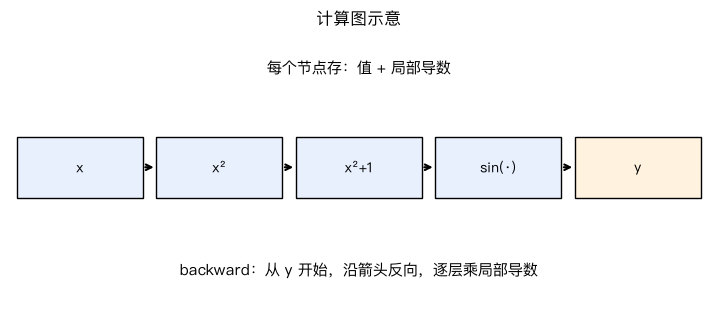

In [2]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.set_xlim(0, 10); ax.set_ylim(0, 4); ax.axis('off')

def box(x, y, text, color='#e8f0fe'):
    ax.add_patch(plt.Rectangle((x-0.9, y-0.45), 1.8, 0.9,
                               fill=True, facecolor=color, edgecolor='black'))
    ax.text(x, y, text, ha='center', va='center', fontsize=10)

pos = [(1, 2), (3, 2), (5, 2), (7, 2), (9, 2)]
labels = ['x', 'x²', 'x²+1', 'sin(·)', 'y']
for (px, py), lab in zip(pos, labels):
    box(px, py, lab, color='#fff3e0' if lab == 'y' else '#e8f0fe')
for a, b in zip(pos[:-1], pos[1:]):
    ax.annotate('', xy=(b[0]-0.9, 2), xytext=(a[0]+0.9, 2),
                arrowprops=dict(arrowstyle='->', lw=1.5))

ax.text(5, 3.4, '每个节点存：值 + 局部导数', ha='center', fontsize=11)
ax.text(5, 0.4, 'backward：从 y 开始，沿箭头反向，逐层乘局部导数', ha='center', fontsize=11)
plt.title('计算图示意')


## 3. 前向模式 vs 反向模式


- **前向模式**：伴随一个方向导数 $\dot{x}$ 从输入往输出传播。对每个输入要单独跑一趟 → 算全部 $n$ 个偏导要 $n$ 趟前向。
- **反向模式**：伴随一个上游梯度 $\bar{v}$ 从输出往输入传播。**一趟**反向就拿到对全部输入的梯度（每个节点只做一次局部乘法）。

深度学习损失是标量：输出 1 个、输入 $n$ 个 → 反向模式只花 $O(n)$，成本约为前向的 2-3 倍（Baur-Strassen 定理）。这就是"反向传播"存在的理由。


In [3]:
# 反向模式：一次 backward 拿到对所有输入的梯度
n = 100
x = torch.randn(n, dtype=torch.float64, requires_grad=True)
y = torch.sin(x).sum() + (x**2).sum()
y.backward()
print(f"n = {n} 个输入：一次反向拿到全部 {x.grad.numel()} 个梯度分量")
print(f"反向模式成本 ≈ 2-3 次前向；前向模式需要 {n} 趟（每趟只对一个输入传播方向）")


n = 100 个输入：一次反向拿到全部 100 个梯度分量
反向模式成本 ≈ 2-3 次前向；前向模式需要 100 趟（每趟只对一个输入传播方向）


## 4. 手写迷你 autograd


### 4.1 设计

每个节点 `Var` 记录四样东西：

- `value`：前向值
- `children`：生成它的父节点（构成计算图）
- `grad_fn`：反向时如何把上游梯度乘局部导数传给父节点
- `grad`：反向传播过程中累积的梯度

`backward()` 先按拓扑序排序（父在前、子在后），再从输出反向遍历，每个节点把自己的 `grad` 通过 `grad_fn` 传给父节点。


In [4]:
class Var:
    """迷你自动微分：支持 + - * / 与 sin、exp 的标量计算图"""
    def __init__(self, value, children=(), grad_fn=None):
        self.value = value
        self.children = children
        self.grad_fn = grad_fn
        self.grad = 0.0

    def backward(self):
        order, seen = [], set()
        def topo(v):
            if id(v) in seen:
                return
            seen.add(id(v))
            for ch in v.children:
                topo(ch)
            order.append(v)
        topo(self)
        self.grad = 1.0                     # d(output)/d(output) = 1
        for v in reversed(order):           # 从输出往输入传播
            if v.grad_fn is not None:
                v.grad_fn(v)

    def _bin(self, other, op):
        other = other if isinstance(other, Var) else Var(other)
        a, b = self, other
        if op == 'add':
            def gf(v):
                a.grad += v.grad
                b.grad += v.grad
            val = a.value + b.value
        elif op == 'mul':
            def gf(v):
                a.grad += v.grad * b.value
                b.grad += v.grad * a.value
            val = a.value * b.value
        elif op == 'div':
            def gf(v):
                a.grad += v.grad / b.value
                b.grad += v.grad * (-a.value / b.value**2)
            val = a.value / b.value
        return Var(val, (a, b), gf)

    def __add__(self, other):  return self._bin(other, 'add')
    def __mul__(self, other):  return self._bin(other, 'mul')
    def __truediv__(self, other): return self._bin(other, 'div')
    def __neg__(self):         return Var(-1.0) * self
    def __sub__(self, other):  return self + (-other)

    def sin(self):
        a = self
        val = np.sin(a.value)
        def gf(v):
            a.grad += v.grad * np.cos(a.value)
        return Var(val, (a,), gf)

    def exp(self):
        a = self
        val = np.exp(a.value)
        def gf(v):
            a.grad += v.grad * val          # d/dx eˣ = eˣ
        return Var(val, (a,), gf)


### 4.2 测试 1：链式法则（与 01 课 3.4 相同的函数）


In [5]:
x = Var(0.9)
y = (x * x + Var(1.0)).sin()        # y = sin(x² + 1)
y.backward()

print("迷你 autograd: dy/dx =", x.grad)
print("解析值        :", np.cos(0.9**2 + 1) * 2 * 0.9)


迷你 autograd: dy/dx = -0.42647228763241446
解析值        : -0.42647228763241446


### 4.3 测试 2：乘法 + 除法 + 减法混合


In [6]:
# y = (x² − 1) / (x + 3)
x = Var(2.0)
y = (x * x - Var(1.0)) / (x + Var(3.0))
y.backward()

# 解析：d/dx (x²-1)/(x+3) = (2x(x+3) − (x²−1)·1)/(x+3)²
manual = (2*2*(2+3) - (4-1)*1) / (2+3)**2
print("迷你 autograd:", x.grad)
print("解析值        :", manual)

# 再测复合：y = sin(x²+1) · eˣ
x = Var(1.1)
a = (x * x + Var(1.0)).sin()
b = x.exp()
y = a * b
y.backward()
manual2 = np.cos(1.1**2+1)*2*1.1*np.exp(1.1) + np.sin(1.1**2+1)*np.exp(1.1)
print("复合函数 autograd:", x.grad)
print("解析值           :", manual2)


迷你 autograd: 0.68
解析值        : 0.68
复合函数 autograd: -1.5316839056853957
解析值           : -1.5316839056853961


## 5. 反向传播在两层网络上的手写实现


以两层 MLP 为例，把第 3 课的记号落地。设输入 $x$，第一层 $z_1 = xW_1 + b_1$、$h = \tanh(z_1)$，第二层 $z_2 = hW_2 + b_2$，损失 $L = \|z_2 - t\|^2$。反向传播从损失往回走：

1. $\partial L/\partial z_2 = 2(z_2 - t)$
2. $\partial L/\partial W_2 = h^\mathsf{T}\cdot \partial L/\partial z_2$，$\partial L/\partial b_2 = \partial L/\partial z_2$
3. $\partial L/\partial h = (\partial L/\partial z_2)\,W_2^\mathsf{T}$（穿过 $W_2$）
4. $\partial L/\partial z_1 = \partial L/\partial h \cdot (1 - h^2)$（$\tanh' = 1-\tanh^2$）
5. $\partial L/\partial W_1 = x^\mathsf{T}\cdot \partial L/\partial z_1$，$\partial L/\partial b_1 = \partial L/\partial z_1$

每一步都是"上游梯度 × 局部导数"，与 torch autograd 对拍：


In [7]:
torch.manual_seed(0)
D_in, H, D_out = 4, 5, 2
W1 = torch.randn(D_in, H, dtype=torch.float64, requires_grad=True)
b1 = torch.randn(H, dtype=torch.float64, requires_grad=True)
W2 = torch.randn(H, D_out, dtype=torch.float64, requires_grad=True)
b2 = torch.randn(D_out, dtype=torch.float64, requires_grad=True)
x = torch.randn(D_in, dtype=torch.float64)
target = torch.randn(D_out, dtype=torch.float64)

# torch 自动求导
h = torch.tanh(x @ W1 + b1)
out = h @ W2 + b2
loss = ((out - target) ** 2).sum()
loss.backward()
gW1_t, gb1_t, gW2_t, gb2_t = W1.grad, b1.grad, W2.grad, b2.grad

# 手写反向传播（用 numpy 复算一遍）
W1n, b1n = W1.detach().numpy(), b1.detach().numpy()
W2n, b2n = W2.detach().numpy(), b2.detach().numpy()
xn, tn = x.numpy(), target.numpy()

z1 = xn @ W1n + b1n
h1 = np.tanh(z1)
z2 = h1 @ W2n + b2n
diff = z2 - tn

dL_dz2 = 2 * diff
dL_dW2 = np.outer(h1, dL_dz2)
dL_db2 = dL_dz2
dL_dh1 = dL_dz2 @ W2n.T
dL_dz1 = dL_dh1 * (1 - h1**2)          # tanh' = 1 - tanh²
dL_dW1 = np.outer(xn, dL_dz1)
dL_db1 = dL_dz1

print("W1 梯度最大误差:", np.abs(gW1_t.numpy() - dL_dW1).max())
print("b1 梯度最大误差:", np.abs(gb1_t.numpy() - dL_db1).max())
print("W2 梯度最大误差:", np.abs(gW2_t.numpy() - dL_dW2).max())
print("b2 梯度最大误差:", np.abs(gb2_t.numpy() - dL_db2).max())


W1 梯度最大误差: 2.463307335887066e-15
b1 梯度最大误差: 8.933825901280557e-16
W2 梯度最大误差: 4.440892098500626e-16
b2 梯度最大误差: 2.220446049250313e-16


## 6. 向量-Jacobian 积（VJP）：张量 autograd 的工作方式


反向传播逐层传播的不是完整 Jacobian，而是"上游梯度向量 $v$ 与局部 Jacobian 的积 $v^\mathsf{T}J$"。张量版本的 `torch.autograd.grad` 用 `grad_outputs` 传入 $v$，返回 VJP——手写 4.3 的 `grad_fn` 其实就是在算 VJP。


In [8]:
x = torch.tensor([0.5, 1.2], dtype=torch.float64, requires_grad=True)
y = torch.stack([x[0]**2, x[0]*x[1], torch.sin(x[1])])
v = torch.tensor([1.0, -2.0, 0.5], dtype=torch.float64)

vjp = torch.autograd.grad(y, x, grad_outputs=v)[0]

def jac_num(f, x, h=1e-6):
    x = np.asarray(x, dtype=float)
    m, n = len(f(x)), len(x)
    J = np.zeros((m, n))
    for j in range(n):
        xp, xm = x.copy(), x.copy()
        xp[j] += h; xm[j] -= h
        J[:, j] = (f(xp) - f(xm)) / (2*h)
    return J

J = jac_num(lambda z: np.array([z[0]**2, z[0]*z[1], np.sin(z[1])]), x.detach().numpy())
print("vᵀJ（torch）:", vjp.numpy())
print("vᵀJ（数值） :", v.numpy() @ J)
print("最大误差:", np.abs(vjp.numpy() - v.numpy() @ J).max())


vᵀJ（torch）: [-1.4        -0.81882112]
vᵀJ（数值） : [-1.4        -0.81882112]
最大误差: 7.827460901665972e-11


## 7. 常见坑


训练中容易踩的三个 autograd 陷阱：

1. **原地操作**：修改了参与计算图的张量，破坏记录 → 报错或梯度错
2. **detach**：从计算图摘除张量，梯度不再流经它（推理/特征提取常用，但要注意语义）
3. **非标量 backward**：多个输出的损失必须提供 `grad_outputs`（权重向量）


In [9]:
# 坑 1：原地操作破坏计算图
x = torch.tensor(1.0, requires_grad=True)
y = x * 2
try:
    x.add_(1.0)          # 原地修改叶子张量
    y.backward()
except RuntimeError as e:
    print("原地操作报错（预期）:", str(e)[:60], "...")


原地操作报错（预期）: a leaf Variable that requires grad is being used in an in-pl ...


In [10]:
# 坑 2：detach 切断梯度流（只影响摘除的那条分支）
x = torch.tensor(2.0, dtype=torch.float64, requires_grad=True)
y = x**2
z = y.detach()                    # 摘除：z 不再携带关于 x 的导数
w = z * 3 + x                     # 两条路径：detach 分支 + 直连分支
w.backward()
print("x.grad =", x.grad.item())
print("解析值：∂w/∂x = ∂(3·detach(x²))/∂x + ∂x/∂x = 0 + 1 = 1（detach 分支贡献 0）")


x.grad = 1.0
解析值：∂w/∂x = ∂(3·detach(x²))/∂x + ∂x/∂x = 0 + 1 = 1（detach 分支贡献 0）


In [11]:
# 坑 3：非标量 backward 需要 grad_outputs
x = torch.tensor([1.0, 2.0], dtype=torch.float64, requires_grad=True)
y = x**2
try:
    y.backward()
except RuntimeError as e:
    print("非标量 backward 报错（预期）:", str(e)[:60], "...")
# 正确做法：给 grad_outputs（上游权重）
x.grad = None
y.backward(torch.tensor([1.0, 1.0], dtype=torch.float64))
print("带 grad_outputs 的梯度:", x.grad)


非标量 backward 报错（预期）: grad can be implicitly created only for scalar outputs ...
带 grad_outputs 的梯度: tensor([2., 4.], dtype=torch.float64)


## 总结


| 本课内容 | 要点 |
|---------|------|
| 三种求导 | 数值（可验证）/ 符号（表达式爆炸）/ 自动（唯一可行） |
| 计算图 | 节点存值 + 局部导数，backward 反向传播 |
| 反向模式 | 标量损失下 $O(n)$ 成本，是前向模式的 $n$ 倍优势 |
| 迷你 autograd | 70 行代码复现链式法则的完整逻辑 |
| VJP | 反向传播只乘向量，不乘矩阵 |
| 常见坑 | 原地操作 / detach / 非标量 backward |

下一课《梯度下降与优化》：有了"精确求梯度"的引擎，开始研究怎么用它高效地下山。


## 课后练习


1. **扩展迷你 autograd**：给 `Var` 增加 `log` 和 `pow`（幂）算子并验证。
2. **手推两层 MLP**：自选输入/隐藏/输出维度，手写反向传播公式并用 torch 对拍（误差 < 1e-10）。
3. **成本分析**：解释为什么标量损失下反向模式只需要 $O(n)$ 而不是 $O(n^2)$？（提示：每层只乘向量）
4. **找 bug**：下面代码的梯度为什么是 0？修复它。
   ```python
   x = torch.tensor(3.0, requires_grad=True)
   y = x * 2
   z = y.detach()
   loss = z ** 2
   loss.backward()
   print(x.grad)
   ```
5. **实现前向模式**：对 $y = \sin(x)\cos(x)$，用"方向导数伴随"的方式（而不是反向）求 $x=1$ 处的导数。
